In [1]:
import snappy
import khovanov
import itertools
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from knot_graphs import *
from geography import *

## Approach: do band moves entirely within kh package
### ~TODO - write `writhe` function for `khovanov.Link`~
### ~TODO - write `normal_euler_number` function for `khovanov.Cobordism`~
### Question: is it the case that $e(F) = - e(F')$ where $F'$ is the surface obtained by mirroring the knots on either end?
### TODO - fix odd normal euler numbers (want $e\equiv 2b_1\bmod 4$)
### TODO - compute $b_1(F)$ within `khovanov`
alternatively, we could try passing to snappy and pray that nothing gets messed up along the way...
### TODO - plot $e(F)$ vs $b_1(F)$

In [2]:
def writhe(link : khovanov.Link):
    link.orient()
    n_plus, n_minus = link.get_signs()
    n = len([c for c in link.crossings if len(c.adjacent) == 4])
    if n_plus + n_minus != n:
        print('something went wrong!')
        print(f'link: {link}')
        print(f'n = {len(link.crossings)}, n+ = {n_plus}, n- = {n_minus}')
    return n_plus - n_minus

In [3]:
def normal_euler_number(cob : khovanov.Cobordism):
    knot = cob.links[0]
    knot_prime = cob.links[-1]

    writhe_orig = writhe(knot)
    writhe_prime = writhe(knot_prime)
    return writhe_prime - writhe_orig

In [4]:
K = snappy.Link('3_1')
K_kh = khovanov.Link(K.PD_code())

['arc3,rad=-0.15', 'arc3,rad=0.15', 'arc3,rad=-0.15', 'arc3,rad=0.15', 'arc3,rad=-0.15', 'arc3,rad=0.15']
{(0, 1, 0): -0.15, (0, 1, 1): 0.15, (1, 2, 0): -0.15, (1, 2, 1): 0.15, (2, 0, 0): -0.15, (2, 0, 1): 0.15}


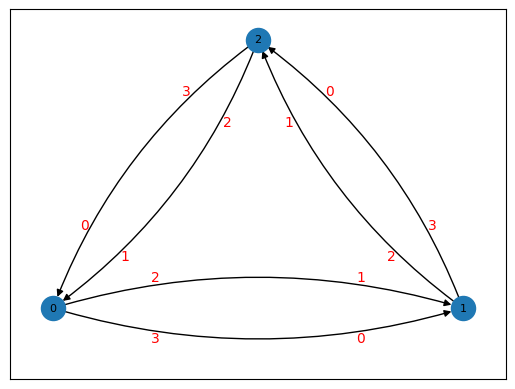

In [5]:
draw_adjacency_graph(K)

In [6]:
cob = khovanov.Cobordism(K_kh)
cob.band_move(0, (0,0), (0,1))
print(normal_euler_number(cob))

6


In [7]:
def try_bands(knot : khovanov.Link):
    crossings = knot.crossings
    strands = [0,1,2,3]
    good_bands = 0
    failed_bands = 0
    twists = []
    c0s = []
    s0s = []
    c1s = []
    s1s = []
    es = []
    for twist in [-1,0,1]:
        for (c0, s0) in itertools.product(crossings, strands):
            for (c1, s1) in itertools.product(crossings, strands):
                if c0 == c1 and s0 == s1: continue
                try:
                    cob = khovanov.Cobordism(knot)
                    cob.band_move(twist, (c0,s0), (c1,s1))
                    e = normal_euler_number(cob)
                    
                    twists.append(twist)
                    c0s.append(c0)
                    s0s.append(s0)
                    c1s.append(c1)
                    s1s.append(s1)
                    es.append(e)
                    
                    good_bands += 1
                except:
                    failed_bands += 1
                    continue

    print(f'bands found: {good_bands}')
    print(f'number of failed band moves: {failed_bands}')
    
    return pd.DataFrame(zip(twists, c0s, s0s, c1s, s1s, es),
                        columns=['twist', 'c0', 's0', 'c1', 's1', 'e'])

In [15]:
def plot_bands(Ksnappy, bands_df,
               erange=(-40,40), brange=(0,30), knot_name=None):
    if knot_name is None:
        knot_name = "?"
        
    fig, ax = plot_bounds(Ksnappy, erange=erange, brange=brange,
                          plot_intersection=False)
    es = bands_df['e']
    #ax.vlines(es, -100, 100, colors='red')

    # plot *possible* points
    e_0s = [e for e in es if e % 4 == 0]
    e_2s = [e for e in es if e % 4 == 2]

    e_pts = []
    b_pts = []
    for e in set(es):
        if e % 4 == 0:
            # plot b_1 = 0,2 mod 4
            for b in range(brange[0], brange[1]+1):
                if b % 4 == 0 or b % 4 == 2:
                    e_pts.append(e)
                    b_pts.append(b)
        elif e % 4 == 2:
            # plot b_1 = 1,3 mod 4
            for b in range(brange[0], brange[1]+1):
                if b % 4 == 1 or b % 4 == 3:
                    e_pts.append(e)
                    b_pts.append(b)

    ax.scatter(e_pts, b_pts, c='red', s=6)
    ax.set_title(f'Possible planar bands on ' + knot_name)
                    
    return fig, ax

### Trefoil $3_1$

In [16]:
bands_K = try_bands(K_kh)
with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(bands_K)

bands found: 228
number of failed band moves: 168


,twist,c0,s0,c1,s1,e
0,-1,0,0,0,2,1
1,-1,0,0,0,3,3
2,-1,0,0,1,2,1
3,-1,0,0,1,3,3
4,-1,0,0,2,2,5
5,-1,0,0,2,3,1
6,-1,0,1,0,2,3
7,-1,0,1,0,3,1
8,-1,0,1,1,2,3
9,-1,0,1,1,3,1


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Possible planar bands on $3_1$'}, xlabel='$e$', ylabel='$b_1$'>)

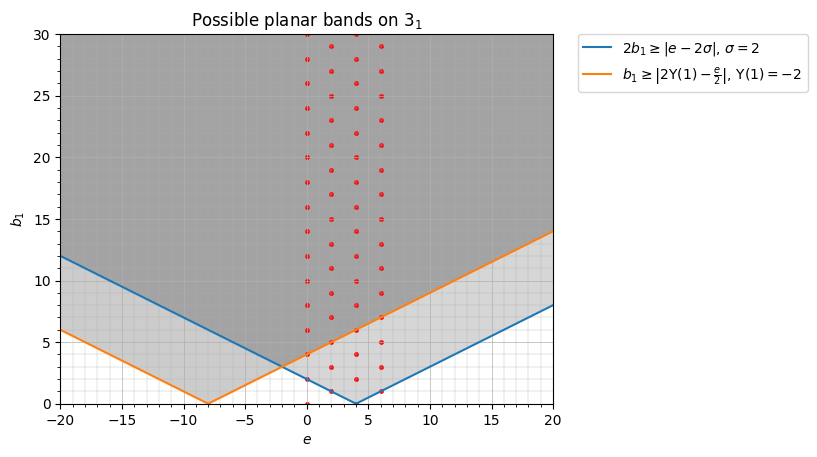

In [18]:
plot_bands(K, bands_K, erange=(-20,20), knot_name='$3_1$')

### Mirrored trefoil $-3_1$

In [20]:
bands_mirror_K = try_bands(K_kh.mirror())
bands_mirror_K
with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(bands_mirror_K)

bands found: 228
number of failed band moves: 168


,twist,c0,s0,c1,s1,e
0,-1,0,0,0,1,-5
1,-1,0,0,0,2,-3
2,-1,0,0,1,1,1
3,-1,0,0,1,2,-7
4,-1,0,0,2,1,-5
5,-1,0,0,2,2,-3
6,-1,0,1,0,0,-5
7,-1,0,1,0,3,-3
8,-1,0,1,1,0,-5
9,-1,0,1,1,3,-3


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Possible planar bands on $-3_1$'}, xlabel='$e$', ylabel='$b_1$'>)

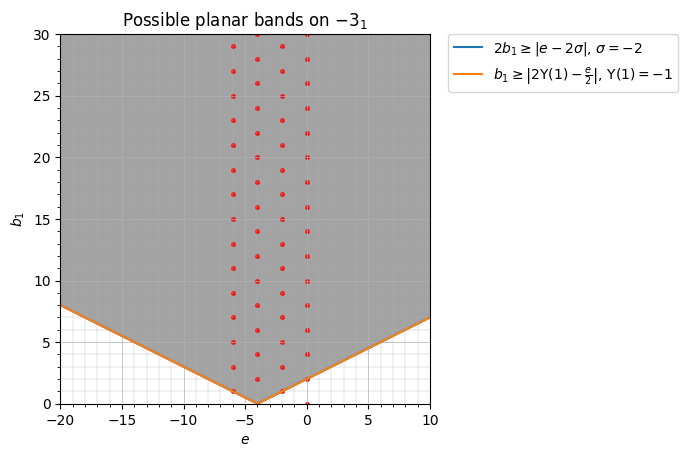

In [21]:
plot_bands(K.mirror(), bands_mirror_K, erange=(-20,10), knot_name='$-3_1$')

### Torus Knots $T(4,q)$

In [22]:
T45 = snappy.Link('T(4,5)')
T45_kh = khovanov.Link(T45.PD_code())
bands_T45 = try_bands(T45_kh)
with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(bands_mirror_K)

bands found: 5460
number of failed band moves: 5160


,twist,c0,s0,c1,s1,e
0,-1,0,0,0,1,-5
1,-1,0,0,0,2,-3
2,-1,0,0,1,1,1
3,-1,0,0,1,2,-7
4,-1,0,0,2,1,-5
5,-1,0,0,2,2,-3
6,-1,0,1,0,0,-5
7,-1,0,1,0,3,-3
8,-1,0,1,1,0,-5
9,-1,0,1,1,3,-3


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Possible planar bands on T(4,5)'}, xlabel='$e$', ylabel='$b_1$'>)

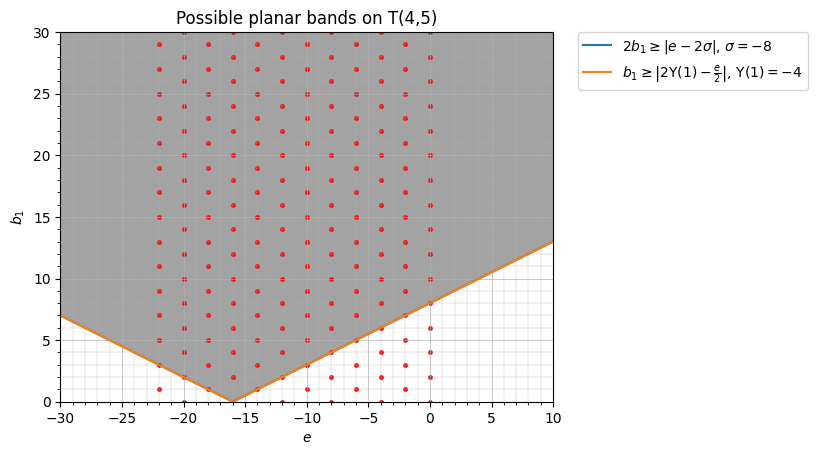

In [23]:
plot_bands(T45, bands_T45, erange=(-30,10), knot_name='T(4,5)')

In [24]:
T47 = snappy.Link('T(4,7)')
T47_kh = khovanov.Link(T45.PD_code())
bands_T47 = try_bands(T47_kh)
with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(bands_mirror_K)

bands found: 5460
number of failed band moves: 5160


,twist,c0,s0,c1,s1,e
0,-1,0,0,0,1,-5
1,-1,0,0,0,2,-3
2,-1,0,0,1,1,1
3,-1,0,0,1,2,-7
4,-1,0,0,2,1,-5
5,-1,0,0,2,2,-3
6,-1,0,1,0,0,-5
7,-1,0,1,0,3,-3
8,-1,0,1,1,0,-5
9,-1,0,1,1,3,-3


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Possible planar bands on T(4,7)'}, xlabel='$e$', ylabel='$b_1$'>)

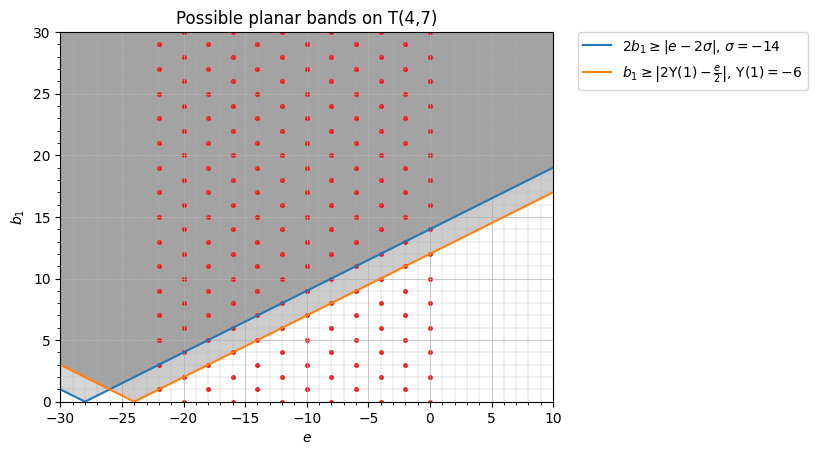

In [25]:
plot_bands(T47, bands_T47, erange=(-30,10), knot_name='T(4,7)')

## ~Approach - write band move function from scratch~

### Bands are described by paths in the dual graph with additional data about over/under crossings at strand intersections

### TODO - draw dual graph on top of adjacency crossing graph

#### the goal here is to draw the dual graph over top of the knot diagram itself

In [ ]:
K = snappy.Link('4_1')
dg = K.dual_graph()

In [ ]:
vars(dg)

In [ ]:
dg_nx = dg.to_networkx()

In [ ]:
dg_nx.nodes.data()

In [ ]:
dg_nx.edges

In [ ]:
def draw_dual_graph(knot):
    dg = knot.dual_graph().to_networkx()
    layout = nx.spring_layout(dg)
    nx.draw_networkx(dg, pos=layout)
    #nx.draw_networkx_labels(dg, pos=layout, font_size=10)

In [ ]:
draw_dual_graph(K)

In [ ]:
draw_adjacency_graph(K)